In [1]:
# ========================================
# LOAN DEFAULT PREDICTION - EDA & MODELING
# Author: [Your Name]
# Date: 2024-03-17
# ========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Libraries imported successfully!")
print(f"📊 Pandas version: {pd.__version__}")
print(f"🔢 NumPy version: {np.__version__}")

✅ Libraries imported successfully!
📊 Pandas version: 3.0.1
🔢 NumPy version: 2.4.3


In [2]:
# ========================================
# 1. DATA LOADING
# ========================================

# Load data
df = pd.read_csv('../data/loan_data.csv')

print("="*70)
print("📂 DATASET LOADED SUCCESSFULLY")
print("="*70)

# Basic info
print(f"\n📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names:\n{df.columns.tolist()}")

# Display first few rows
print(f"\n🔍 First 5 Rows:")
df.head()

📂 DATASET LOADED SUCCESSFULLY

📊 Dataset Shape: 614 rows × 13 columns

📋 Column Names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

🔍 First 5 Rows:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
# ========================================
# 2. DATA OVERVIEW
# ========================================

print("="*70)
print("📊 DATA OVERVIEW")
print("="*70)

# Data types
print("\n📋 Data Types:")
print(df.dtypes)

# Statistical summary
print("\n📈 Statistical Summary (Numerical Features):")
print(df.describe())

# Info
print("\n📊 Dataset Info:")
df.info()

📊 DATA OVERVIEW

📋 Data Types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

📈 Statistical Summary (Numerical Features):
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%     

🔍 MISSING VALUES ANALYSIS

📋 Missing Values Summary:
          Column  Missing_Count  Missing_Percentage
  Credit_History             50            8.143322
   Self_Employed             32            5.211726
      LoanAmount             22            3.583062
      Dependents             15            2.442997
Loan_Amount_Term             14            2.280130
          Gender             13            2.117264
         Married              3            0.488599


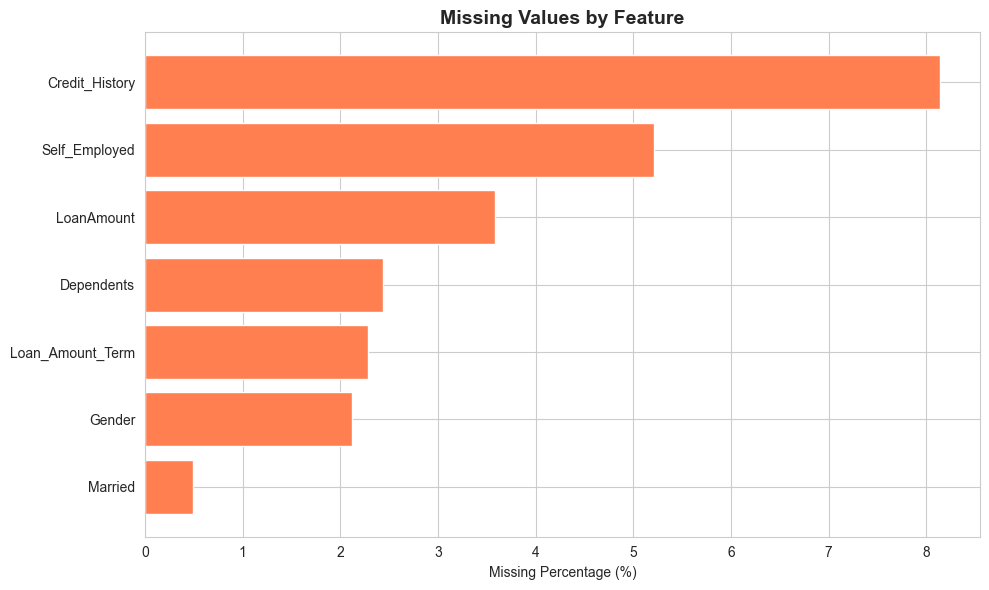


📊 Total columns with missing values: 7


In [4]:
# ========================================
# 3. MISSING VALUES ANALYSIS
# ========================================

print("="*70)
print("🔍 MISSING VALUES ANALYSIS")
print("="*70)

# Calculate missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

# Create missing values dataframe
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing_Count': missing_values.values,
    'Missing_Percentage': missing_percent.values
})

# Filter only columns with missing values
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

print("\n📋 Missing Values Summary:")
print(missing_df.to_string(index=False))

# Visualize missing values
plt.figure(figsize=(10, 6))
missing_df_sorted = missing_df.sort_values('Missing_Percentage', ascending=True)
plt.barh(missing_df_sorted['Column'], missing_df_sorted['Missing_Percentage'], color='coral')
plt.xlabel('Missing Percentage (%)')
plt.title('Missing Values by Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Total columns with missing values: {len(missing_df)}")

🎯 TARGET VARIABLE ANALYSIS (Loan_Status)

📊 Loan Status Distribution:
Status  Count  Percentage
     Y    422   68.729642
     N    192   31.270358


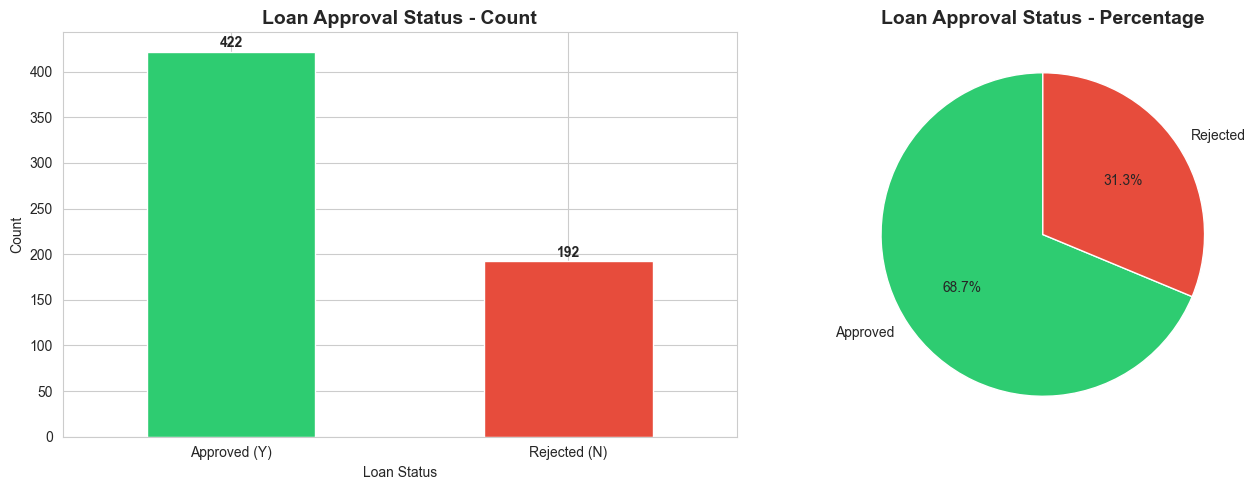


⚖️ Class Imbalance Ratio: 2.20
⚠️ WARNING: Dataset is imbalanced. Consider using SMOTE or class_weight in models.


In [5]:
# ========================================
# 4. TARGET VARIABLE ANALYSIS
# ========================================

print("="*70)
print("🎯 TARGET VARIABLE ANALYSIS (Loan_Status)")
print("="*70)

# Value counts
target_counts = df['Loan_Status'].value_counts()
target_percent = df['Loan_Status'].value_counts(normalize=True) * 100

print("\n📊 Loan Status Distribution:")
print(pd.DataFrame({
    'Status': target_counts.index,
    'Count': target_counts.values,
    'Percentage': target_percent.values
}).to_string(index=False))

# Visualize target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Loan Approval Status - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Approved (Y)', 'Rejected (N)'], rotation=0)

# Add count labels on bars
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(target_counts.values, labels=['Approved', 'Rejected'], 
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[1].set_title('Loan Approval Status - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Check for class imbalance
imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\n⚖️ Class Imbalance Ratio: {imbalance_ratio:.2f}")

if imbalance_ratio > 2:
    print("⚠️ WARNING: Dataset is imbalanced. Consider using SMOTE or class_weight in models.")
else:
    print("✅ Dataset is relatively balanced.")

📊 CATEGORICAL FEATURES ANALYSIS

📋 Categorical Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']

📊 Gender
Gender
Male      489
Female    112
Name: count, dtype: int64

Unique values: 2

📊 Married
Married
Yes    398
No     213
Name: count, dtype: int64

Unique values: 2

📊 Dependents
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

Unique values: 4

📊 Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

Unique values: 2

📊 Self_Employed
Self_Employed
No     500
Yes     82
Name: count, dtype: int64

Unique values: 2

📊 Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

Unique values: 3


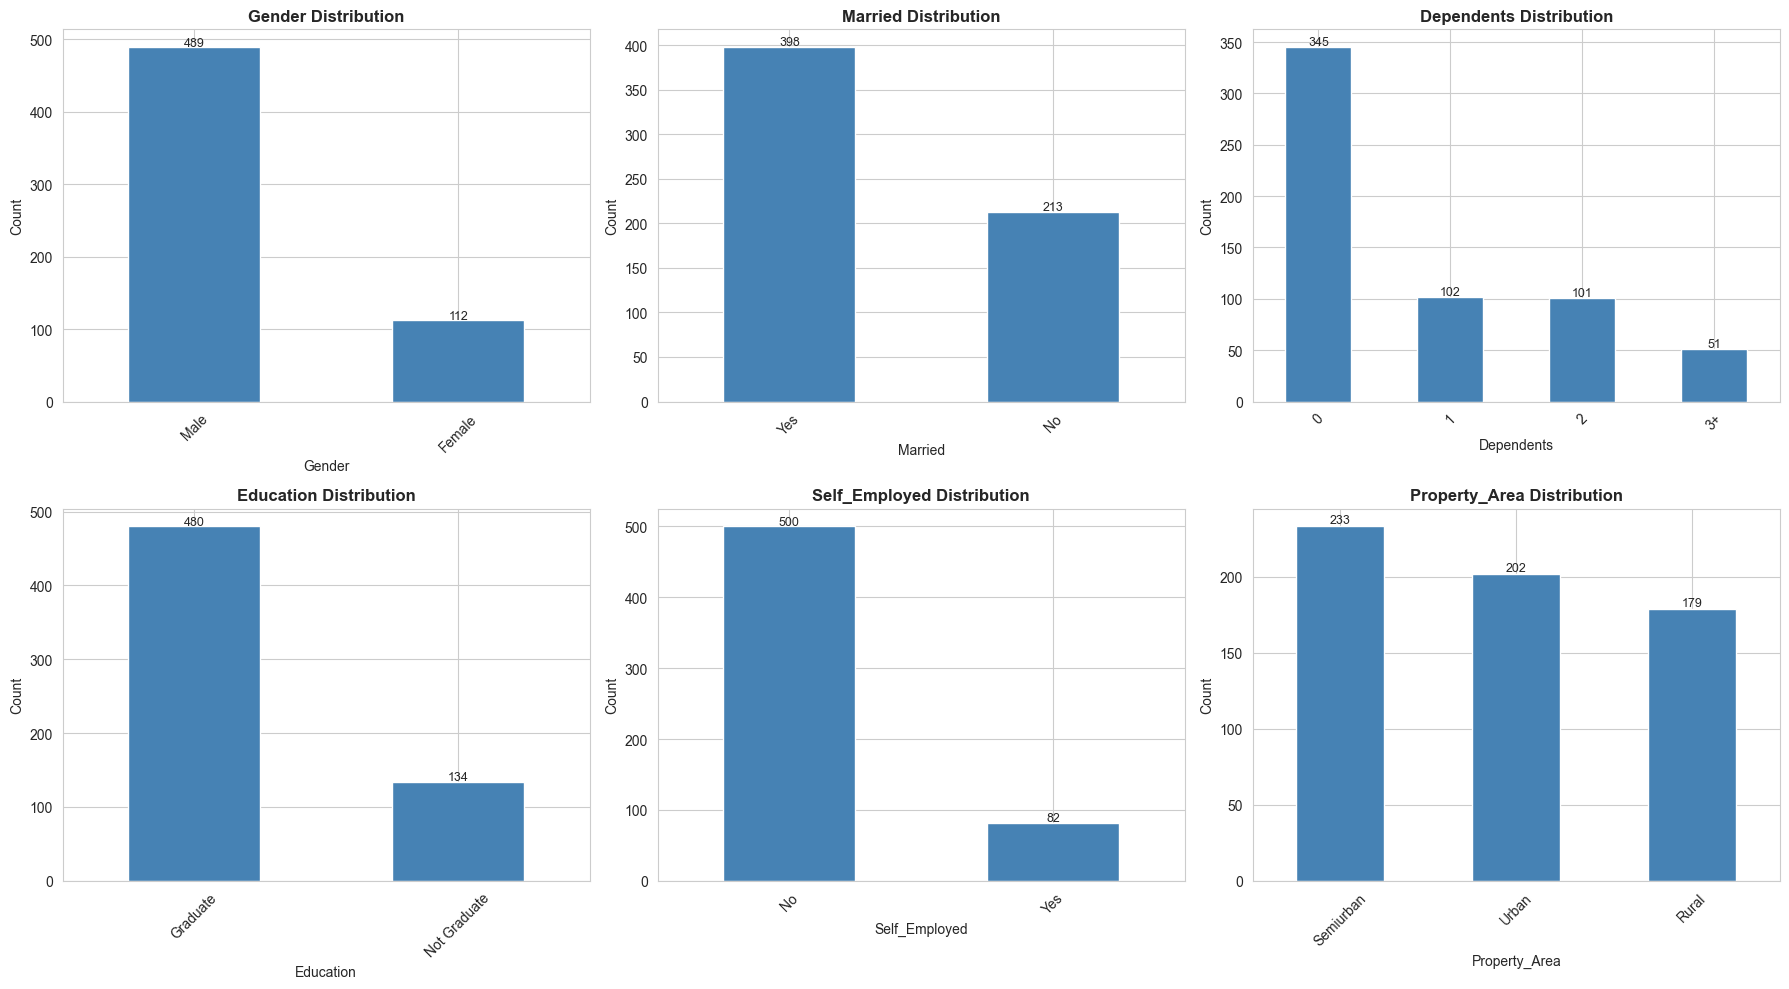

In [6]:
# ========================================
# 5. UNIVARIATE ANALYSIS - CATEGORICAL FEATURES
# ========================================

print("="*70)
print("📊 CATEGORICAL FEATURES ANALYSIS")
print("="*70)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols.remove('Loan_ID')  # Remove ID column
categorical_cols.remove('Loan_Status')  # Remove target

print(f"\n📋 Categorical Features: {categorical_cols}")

# Analyze each categorical feature
for col in categorical_cols:
    print(f"\n{'='*70}")
    print(f"📊 {col}")
    print(f"{'='*70}")
    
    counts = df[col].value_counts()
    print(counts)
    print(f"\nUnique values: {df[col].nunique()}")

# Visualize categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add count labels
        for j, v in enumerate(df[col].value_counts().values):
            axes[i].text(j, v + 2, str(v), ha='center', fontsize=9)

# Hide extra subplots if any
for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

🔢 NUMERICAL FEATURES ANALYSIS

📋 Numerical Features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

📊 Statistical Summary:
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%       

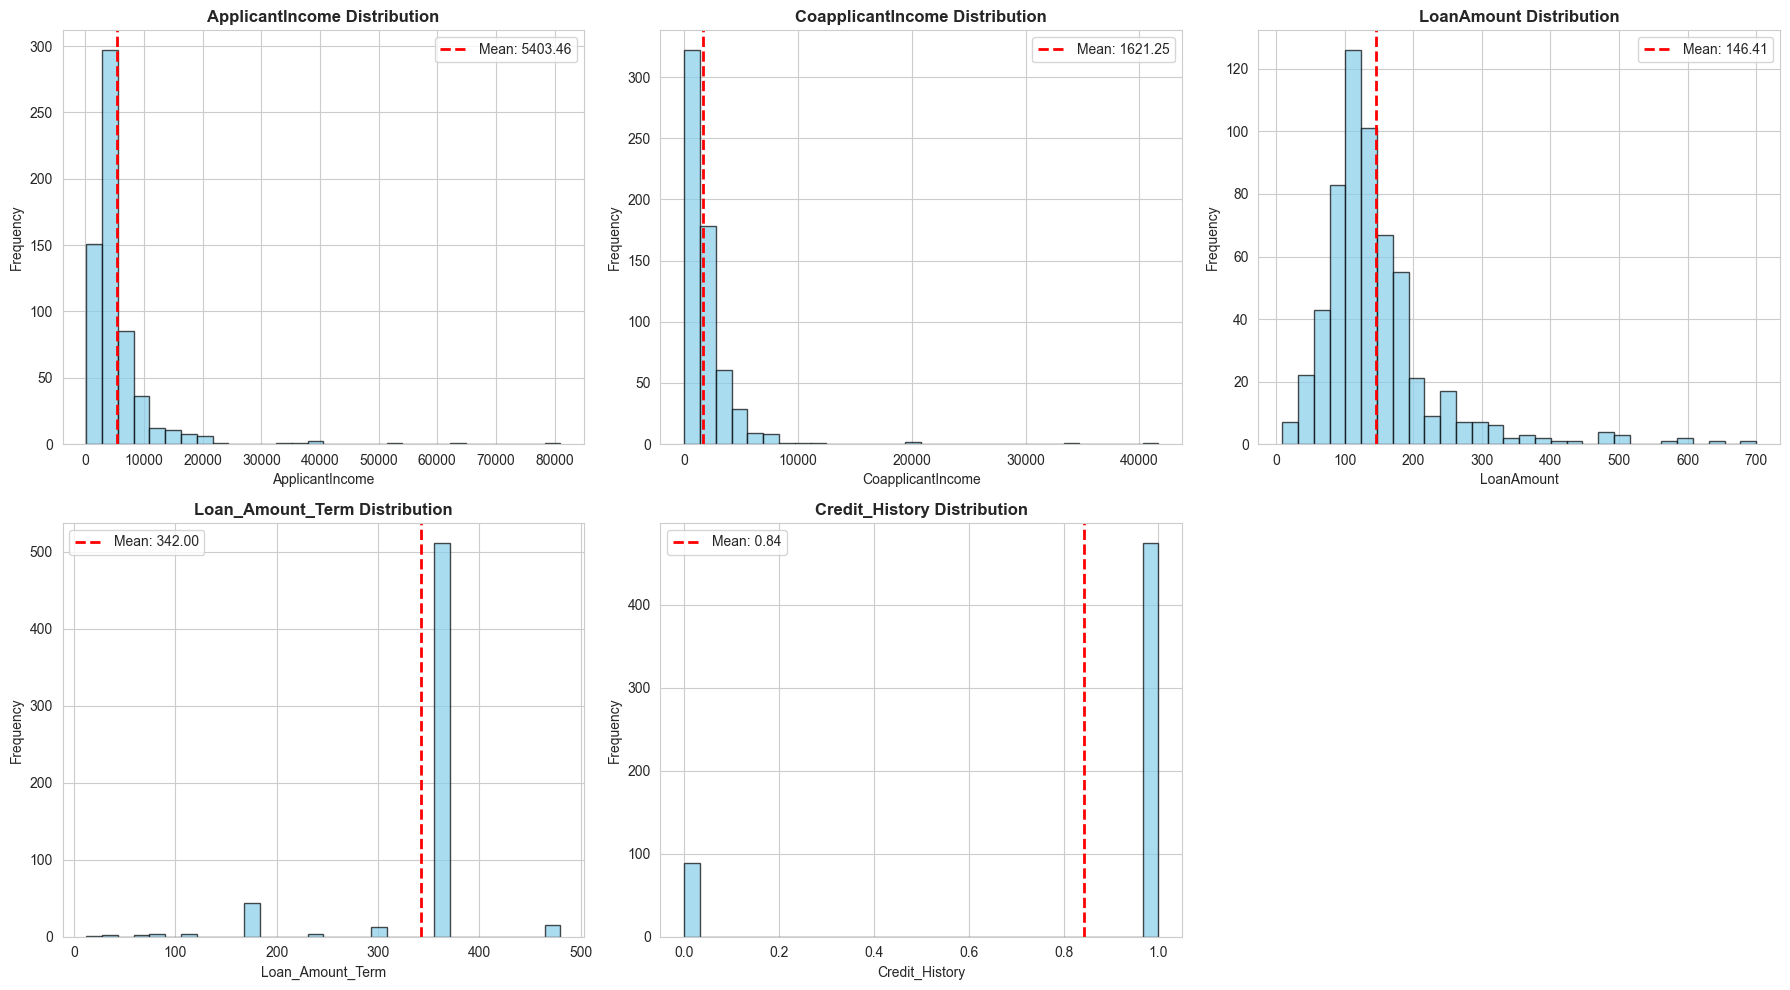

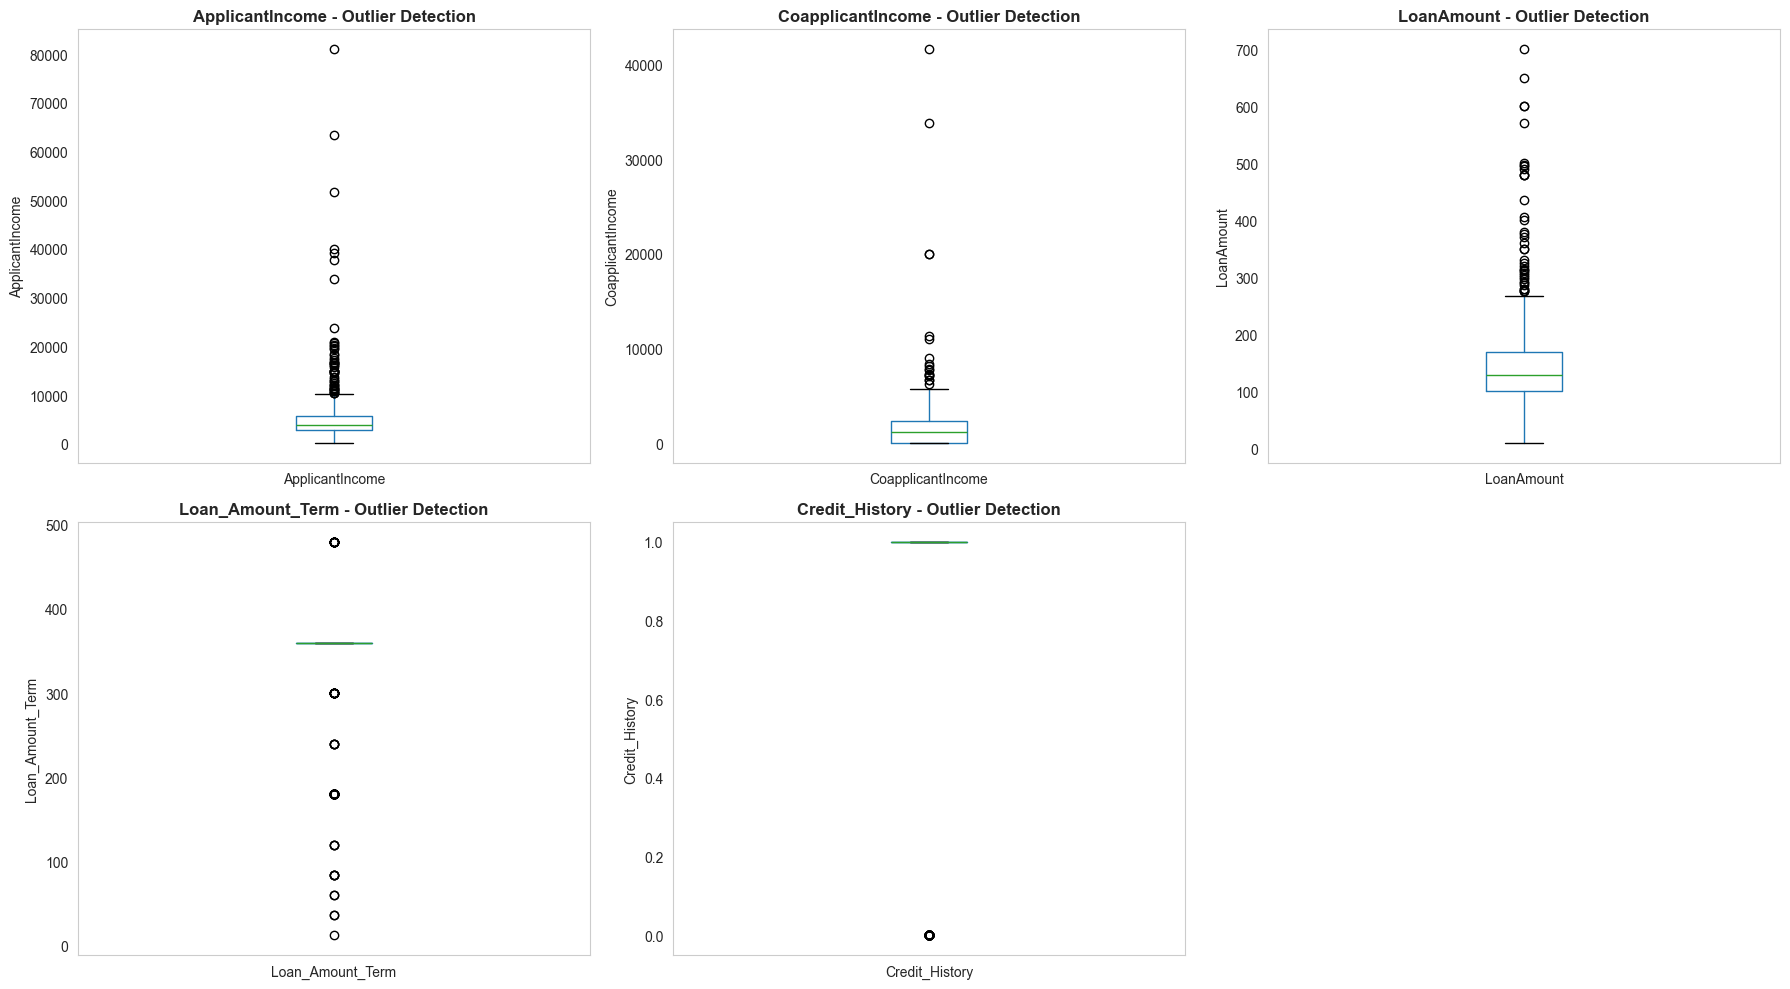

In [7]:
# ========================================
# 6. UNIVARIATE ANALYSIS - NUMERICAL FEATURES
# ========================================

print("="*70)
print("🔢 NUMERICAL FEATURES ANALYSIS")
print("="*70)

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"\n📋 Numerical Features: {numerical_cols}")

# Statistical summary
print("\n📊 Statistical Summary:")
print(df[numerical_cols].describe())

# Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        # Histogram with KDE
        df[col].dropna().hist(bins=30, ax=axes[i], color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')
        
        # Add mean line
        mean_val = df[col].mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
        axes[i].legend()

# Hide extra subplots if any
for i in range(len(numerical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Box plots to identify outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        df.boxplot(column=col, ax=axes[i], grid=False)
        axes[i].set_title(f'{col} - Outlier Detection', fontsize=12, fontweight='bold')
        axes[i].set_ylabel(col)

# Hide extra subplots
for i in range(len(numerical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

📊 BIVARIATE ANALYSIS: CATEGORICAL FEATURES vs LOAN STATUS

📊 Gender - Approval Rates:
Gender
Female    66.964286
Male      69.325153

📊 Married - Approval Rates:
Married
No     62.910798
Yes    71.608040

📊 Dependents - Approval Rates:
Dependents
0     68.985507
1     64.705882
2     75.247525
3+    64.705882

📊 Education - Approval Rates:
Education
Graduate        70.833333
Not Graduate    61.194030

📊 Self_Employed - Approval Rates:
Self_Employed
No     68.600000
Yes    68.292683

📊 Property_Area - Approval Rates:
Property_Area
Rural        61.452514
Semiurban    76.824034
Urban        65.841584


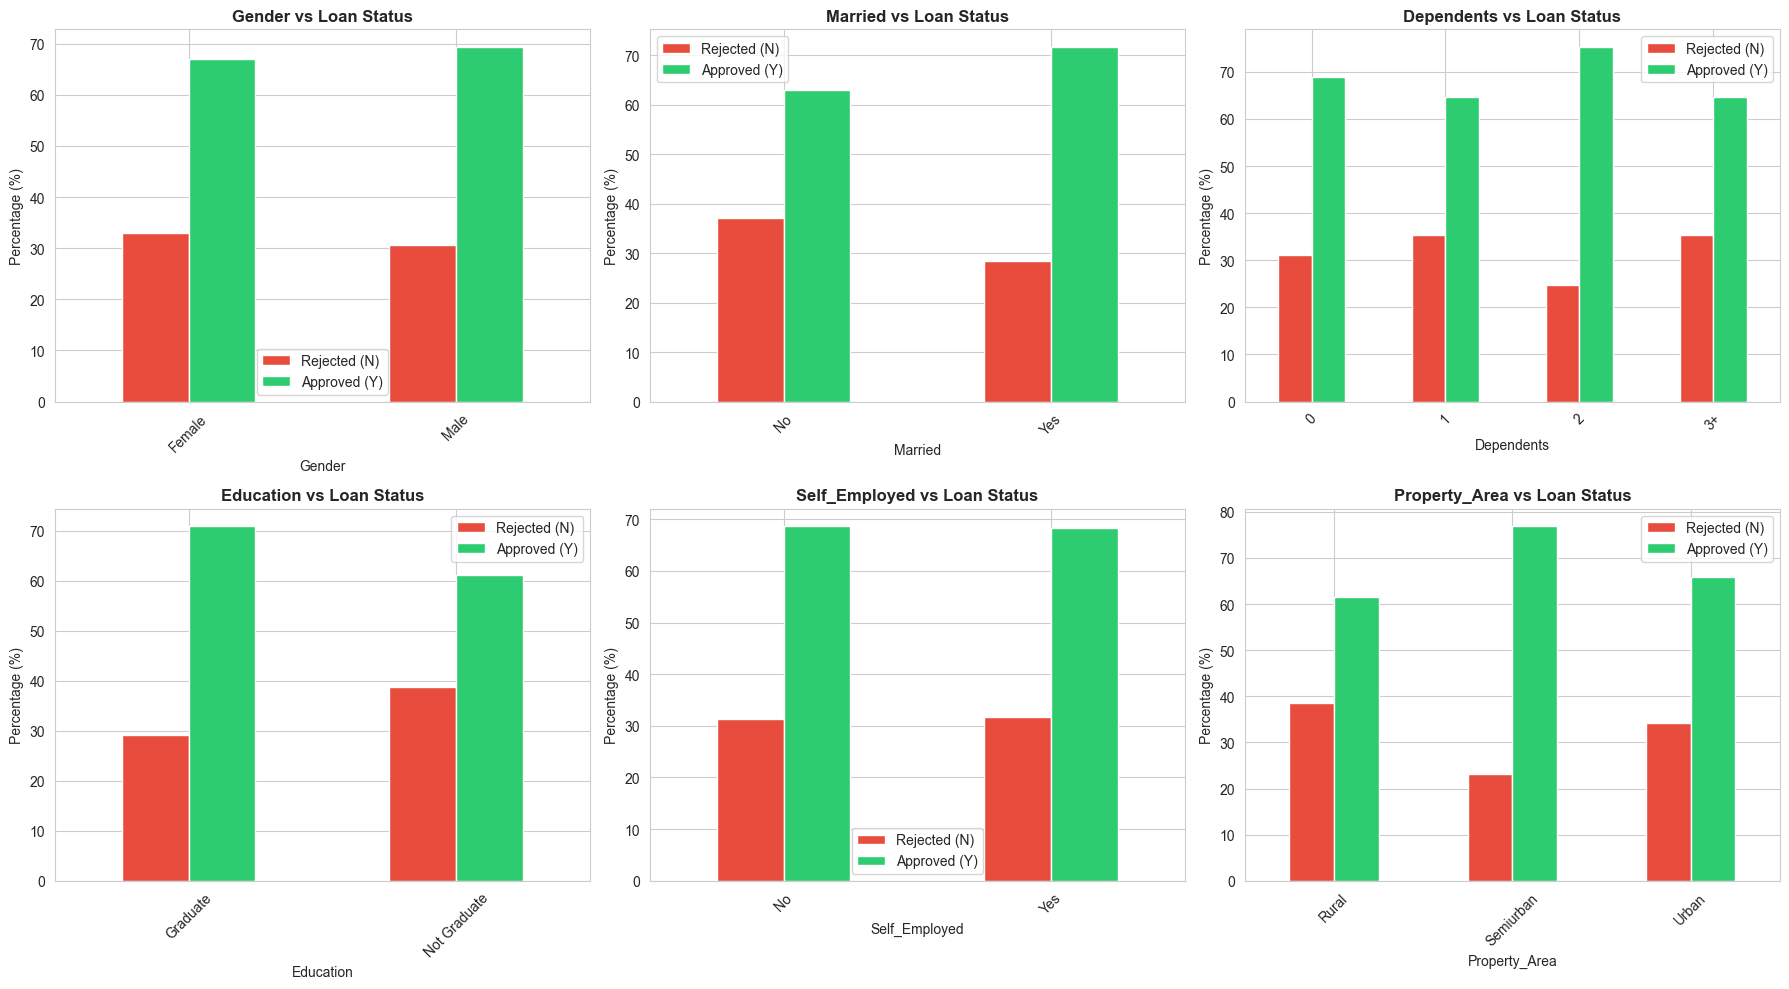

In [8]:
# ========================================
# 7. BIVARIATE ANALYSIS - CATEGORICAL vs TARGET
# ========================================

print("="*70)
print("📊 BIVARIATE ANALYSIS: CATEGORICAL FEATURES vs LOAN STATUS")
print("="*70)

# Analyze relationship between categorical features and target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        # Create crosstab
        ct = pd.crosstab(df[col], df['Loan_Status'], normalize='index') * 100
        
        # Plot
        ct.plot(kind='bar', ax=axes[i], stacked=False, color=['#e74c3c', '#2ecc71'])
        axes[i].set_title(f'{col} vs Loan Status', fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Percentage (%)')
        axes[i].set_xlabel(col)
        axes[i].legend(['Rejected (N)', 'Approved (Y)'], loc='best')
        axes[i].tick_params(axis='x', rotation=45)
        
        # Print approval rates
        print(f"\n📊 {col} - Approval Rates:")
        approval_rates = pd.crosstab(df[col], df['Loan_Status'], normalize='index')['Y'] * 100
        print(approval_rates.to_string())

# Hide extra subplots
for i in range(len(categorical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

📊 BIVARIATE ANALYSIS: NUMERICAL FEATURES vs LOAN STATUS

📊 ApplicantIncome - Mean by Loan Status:
Loan_Status
N    5446.078125
Y    5384.068720
Name: ApplicantIncome, dtype: float64

📊 CoapplicantIncome - Mean by Loan Status:
Loan_Status
N    1877.807292
Y    1504.516398
Name: CoapplicantIncome, dtype: float64

📊 LoanAmount - Mean by Loan Status:
Loan_Status
N    151.220994
Y    144.294404
Name: LoanAmount, dtype: float64

📊 Loan_Amount_Term - Mean by Loan Status:
Loan_Status
N    344.064516
Y    341.072464
Name: Loan_Amount_Term, dtype: float64

📊 Credit_History - Mean by Loan Status:
Loan_Status
N    0.541899
Y    0.981818
Name: Credit_History, dtype: float64


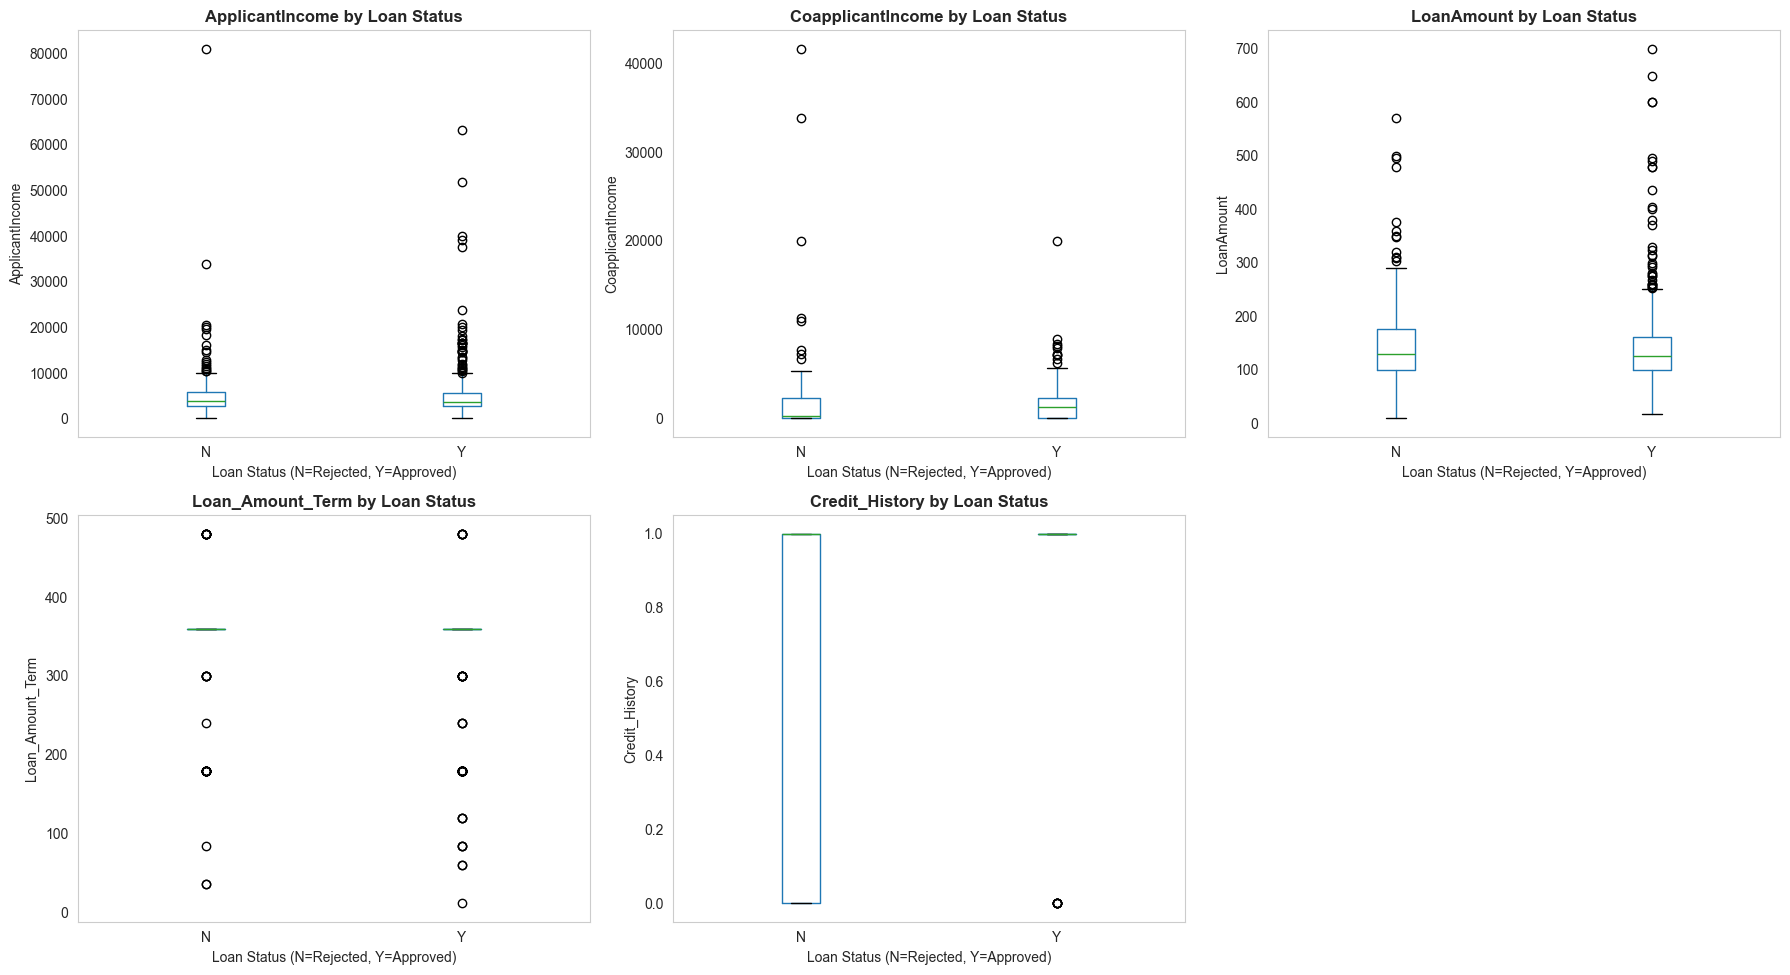

In [9]:
# ========================================
# 8. BIVARIATE ANALYSIS - NUMERICAL vs TARGET
# ========================================

print("="*70)
print("📊 BIVARIATE ANALYSIS: NUMERICAL FEATURES vs LOAN STATUS")
print("="*70)

# Box plots for numerical features by loan status
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if i < len(axes):
        df.boxplot(column=col, by='Loan_Status', ax=axes[i], grid=False)
        axes[i].set_title(f'{col} by Loan Status', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('Loan Status (N=Rejected, Y=Approved)')
        axes[i].set_ylabel(col)
        
        # Print mean comparison
        print(f"\n📊 {col} - Mean by Loan Status:")
        print(df.groupby('Loan_Status')[col].mean())

plt.suptitle('')  # Remove default title
for i in range(len(numerical_cols), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

🔗 CORRELATION ANALYSIS

📊 Correlation Matrix:
                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome           1.000000          -0.116605    0.570909   
CoapplicantIncome        -0.116605           1.000000    0.188619   
LoanAmount                0.570909           0.188619    1.000000   
Loan_Amount_Term         -0.045306          -0.059878    0.039447   
Credit_History           -0.014715          -0.002056   -0.008433   

                   Loan_Amount_Term  Credit_History  
ApplicantIncome           -0.045306       -0.014715  
CoapplicantIncome         -0.059878       -0.002056  
LoanAmount                 0.039447       -0.008433  
Loan_Amount_Term           1.000000        0.001470  
Credit_History             0.001470        1.000000  


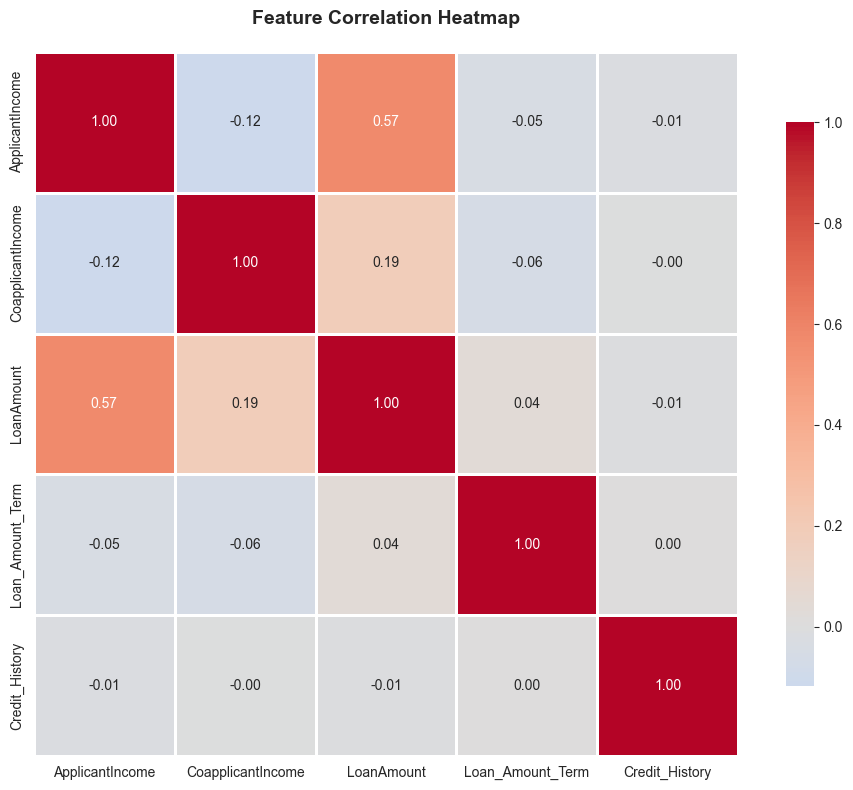


🔍 Highly Correlated Feature Pairs (correlation > 0.7):
✅ No highly correlated features found (|correlation| > 0.7)


In [10]:
# ========================================
# 9. CORRELATION ANALYSIS
# ========================================

print("="*70)
print("🔗 CORRELATION ANALYSIS")
print("="*70)

# Calculate correlation matrix for numerical features
correlation_matrix = df[numerical_cols].corr()

print("\n📊 Correlation Matrix:")
print(correlation_matrix)

# Visualize correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated features
print("\n🔍 Highly Correlated Feature Pairs (correlation > 0.7):")
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if high_corr:
    print(pd.DataFrame(high_corr).to_string(index=False))
else:
    print("✅ No highly correlated features found (|correlation| > 0.7)")

In [11]:
# ========================================
# 10. DATA CLEANING - MISSING VALUES
# ========================================

print("="*70)
print("🧹 DATA CLEANING: HANDLING MISSING VALUES")
print("="*70)

# Create a copy for cleaning
df_clean = df.copy()

print(f"\n📊 Original dataset shape: {df_clean.shape}")
print(f"\n🔍 Missing values before cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Strategy for handling missing values:
# 1. Gender: Fill with mode (most frequent)
# 2. Married: Fill with mode
# 3. Dependents: Fill with mode
# 4. Self_Employed: Fill with mode
# 5. LoanAmount: Fill with median (less affected by outliers)
# 6. Loan_Amount_Term: Fill with mode
# 7. Credit_History: Fill with mode (most critical feature)

# Categorical features - fill with mode
categorical_features = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History']
for col in categorical_features:
    if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
        mode_value = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_value, inplace=True)
        print(f"✅ {col}: Filled {df[col].isnull().sum()} missing values with mode '{mode_value}'")

# Numerical feature - fill with median
if 'LoanAmount' in df_clean.columns and df_clean['LoanAmount'].isnull().sum() > 0:
    median_value = df_clean['LoanAmount'].median()
    df_clean['LoanAmount'].fillna(median_value, inplace=True)
    print(f"✅ LoanAmount: Filled {df['LoanAmount'].isnull().sum()} missing values with median {median_value:.2f}")

print(f"\n🔍 Missing values after cleaning:")
missing_after = df_clean.isnull().sum()
if missing_after.sum() == 0:
    print("✅ No missing values remaining!")
else:
    print(missing_after[missing_after > 0])

print(f"\n📊 Cleaned dataset shape: {df_clean.shape}")

🧹 DATA CLEANING: HANDLING MISSING VALUES

📊 Original dataset shape: (614, 13)

🔍 Missing values before cleaning:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64
✅ Gender: Filled 13 missing values with mode 'Male'
✅ Married: Filled 3 missing values with mode 'Yes'
✅ Dependents: Filled 15 missing values with mode '0'
✅ Self_Employed: Filled 32 missing values with mode 'No'
✅ Loan_Amount_Term: Filled 14 missing values with mode '360.0'
✅ Credit_History: Filled 50 missing values with mode '1.0'
✅ LoanAmount: Filled 22 missing values with median 128.00

🔍 Missing values after cleaning:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64

📊 Cleaned dataset shape: (614, 13)


In [12]:
# ========================================
# 11. FEATURE ENGINEERING
# ========================================

print("="*70)
print("⚙️ FEATURE ENGINEERING")
print("="*70)

# Create new features
print("\n🔧 Creating new features...\n")

# 1. Total Income
df_clean['TotalIncome'] = df_clean['ApplicantIncome'] + df_clean['CoapplicantIncome']
print("✅ Created: TotalIncome = ApplicantIncome + CoapplicantIncome")

# 2. Loan Amount to Income Ratio
df_clean['LoanAmountToIncome'] = df_clean['LoanAmount'] / df_clean['TotalIncome']
print("✅ Created: LoanAmountToIncome = LoanAmount / TotalIncome")

# 3. Income per Dependent
df_clean['Dependents_numeric'] = df_clean['Dependents'].replace({'3+': 3}).astype(float)
df_clean['IncomePerDependent'] = df_clean['TotalIncome'] / (df_clean['Dependents_numeric'] + 1)
print("✅ Created: IncomePerDependent = TotalIncome / (Dependents + 1)")

# 4. Log transformations for skewed features (to normalize distributions)
df_clean['LoanAmount_log'] = np.log(df_clean['LoanAmount'] + 1)
df_clean['TotalIncome_log'] = np.log(df_clean['TotalIncome'] + 1)
print("✅ Created: LoanAmount_log and TotalIncome_log (log transformations)")

# 5. Binary encoding for categorical features
df_clean['Gender_binary'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})
df_clean['Married_binary'] = df_clean['Married'].map({'Yes': 1, 'No': 0})
df_clean['Education_binary'] = df_clean['Education'].map({'Graduate': 1, 'Not Graduate': 0})
df_clean['Self_Employed_binary'] = df_clean['Self_Employed'].map({'Yes': 1, 'No': 0})
print("✅ Created: Binary encodings for Gender, Married, Education, Self_Employed")

# 6. Target encoding (convert Y/N to 1/0)
df_clean['Loan_Status_binary'] = df_clean['Loan_Status'].map({'Y': 1, 'N': 0})
print("✅ Created: Loan_Status_binary (1=Approved, 0=Rejected)")

print(f"\n📊 Dataset shape after feature engineering: {df_clean.shape}")
print(f"📋 New columns added: {df_clean.shape[1] - df.shape[1]}")

# Display new features
print("\n🔍 Preview of new features:")
new_features = ['TotalIncome', 'LoanAmountToIncome', 'IncomePerDependent', 
                'LoanAmount_log', 'TotalIncome_log', 'Loan_Status_binary']
print(df_clean[new_features].head(10))

⚙️ FEATURE ENGINEERING

🔧 Creating new features...

✅ Created: TotalIncome = ApplicantIncome + CoapplicantIncome
✅ Created: LoanAmountToIncome = LoanAmount / TotalIncome
✅ Created: IncomePerDependent = TotalIncome / (Dependents + 1)
✅ Created: LoanAmount_log and TotalIncome_log (log transformations)
✅ Created: Binary encodings for Gender, Married, Education, Self_Employed
✅ Created: Loan_Status_binary (1=Approved, 0=Rejected)

📊 Dataset shape after feature engineering: (614, 24)
📋 New columns added: 11

🔍 Preview of new features:
   TotalIncome  LoanAmountToIncome  IncomePerDependent  LoanAmount_log  \
0       5849.0                 NaN         5849.000000             NaN   
1       6091.0            0.021015         3045.500000        4.859812   
2       3000.0            0.022000         3000.000000        4.204693   
3       4941.0            0.024287         4941.000000        4.795791   
4       6000.0            0.023500         6000.000000        4.955827   
5       9613.0      

In [16]:
# ========================================
# 12. ENCODE CATEGORICAL VARIABLES
# ========================================

print("="*70)
print("🔤 ENCODING CATEGORICAL VARIABLES")
print("="*70)

from sklearn.preprocessing import LabelEncoder

# Create a copy for encoding
df_encoded = df_clean.copy()

# First, let's check what values exist in Property_Area
print(f"\n🔍 Property_Area unique values:")
print(df_encoded['Property_Area'].value_counts())

# Property Area - One-Hot Encoding (3 categories)
# Using drop_first=True to avoid multicollinearity
property_dummies = pd.get_dummies(df_encoded['Property_Area'], prefix='Property_Area', drop_first=True)
df_encoded = pd.concat([df_encoded, property_dummies], axis=1)

print(f"\n✅ One-Hot Encoded: Property_Area")
print(f"   New columns created: {property_dummies.columns.tolist()}")

# Display sample of encoded data
print(f"\n📊 Sample of encoded Property_Area:")
print(df_encoded[['Property_Area'] + property_dummies.columns.tolist()].head(10))

print(f"\n📊 Final dataset shape: {df_encoded.shape}")

🔤 ENCODING CATEGORICAL VARIABLES

🔍 Property_Area unique values:
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

✅ One-Hot Encoded: Property_Area
   New columns created: ['Property_Area_Semiurban', 'Property_Area_Urban']

📊 Sample of encoded Property_Area:
  Property_Area  Property_Area_Semiurban  Property_Area_Urban
0         Urban                    False                 True
1         Rural                    False                False
2         Urban                    False                 True
3         Urban                    False                 True
4         Urban                    False                 True
5         Urban                    False                 True
6         Urban                    False                 True
7     Semiurban                     True                False
8         Urban                    False                 True
9     Semiurban                     True                False

📊 Final dataset 

In [17]:
# ========================================
# 13. PREPARE DATA FOR MODELING
# ========================================

print("="*70)
print("📊 PREPARING DATA FOR MODELING")
print("="*70)

# First, let's see all available columns
print("\n📋 Available columns in df_encoded:")
print(df_encoded.columns.tolist())

# Select features for modeling
feature_columns = [
    # Original numerical features
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History',
    
    # Engineered features
    'TotalIncome',
    'LoanAmountToIncome',
    'IncomePerDependent',
    'LoanAmount_log',
    'TotalIncome_log',
    
    # Binary encoded features
    'Gender_binary',
    'Married_binary',
    'Education_binary',
    'Self_Employed_binary',
    'Dependents_numeric',
    
    # One-hot encoded features (CORRECTED NAMES)
    'Property_Area_Semiurban',
    'Property_Area_Urban'
    # Note: Rural is the reference category (dropped), so it's encoded as 0,0
]

# Verify all columns exist
print("\n🔍 Verifying feature columns...")
missing_cols = [col for col in feature_columns if col not in df_encoded.columns]
if missing_cols:
    print(f"❌ Missing columns: {missing_cols}")
    print("\n⚠️ Please check the column names in df_encoded")
else:
    print("✅ All feature columns found!")

# Target variable
target_column = 'Loan_Status_binary'

# Create X (features) and y (target)
X = df_encoded[feature_columns].copy()
y = df_encoded[target_column].copy()

print(f"\n✅ Features (X) shape: {X.shape}")
print(f"✅ Target (y) shape: {y.shape}")

print(f"\n📋 Selected Features ({len(feature_columns)}):")
for i, col in enumerate(feature_columns, 1):
    print(f"   {i:2d}. {col}")

print(f"\n🎯 Target Distribution:")
print(y.value_counts())
print(f"\n   Approved (1): {(y==1).sum()} ({(y==1).sum()/len(y)*100:.2f}%)")
print(f"   Rejected (0): {(y==0).sum()} ({(y==0).sum()/len(y)*100:.2f}%)")

# Check for any remaining missing values
print(f"\n🔍 Missing values check:")
missing_in_X = X.isnull().sum().sum()
missing_in_y = y.isnull().sum()

if missing_in_X == 0 and missing_in_y == 0:
    print("   ✅ No missing values in feature set or target")
else:
    if missing_in_X > 0:
        print(f"   ⚠️ Warning: {missing_in_X} missing values in features:")
        print(X.isnull().sum()[X.isnull().sum() > 0])
    if missing_in_y > 0:
        print(f"   ⚠️ Warning: {missing_in_y} missing values in target")

# Handle any remaining NaN/Inf values in features
print("\n🧹 Cleaning infinite and NaN values...")
# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Check for NaN after inf replacement
if X.isnull().sum().sum() > 0:
    print(f"   ⚠️ Found {X.isnull().sum().sum()} NaN values after inf replacement")
    print("   Filling with median values...")
    X = X.fillna(X.median())
    print("   ✅ NaN values filled")
else:
    print("   ✅ No infinite or NaN values found")

# Final verification
print(f"\n✅ FINAL DATA READY:")
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")
print(f"   Total samples: {len(X)}")

# Display first few rows
print(f"\n🔍 First 5 rows of feature matrix:")
print(X.head())

📊 PREPARING DATA FOR MODELING

📋 Available columns in df_encoded:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'TotalIncome', 'LoanAmountToIncome', 'Dependents_numeric', 'IncomePerDependent', 'LoanAmount_log', 'TotalIncome_log', 'Gender_binary', 'Married_binary', 'Education_binary', 'Self_Employed_binary', 'Loan_Status_binary', 'Property_Area_Semiurban', 'Property_Area_Urban']

🔍 Verifying feature columns...
✅ All feature columns found!

✅ Features (X) shape: (614, 17)
✅ Target (y) shape: (614,)

📋 Selected Features (17):
    1. ApplicantIncome
    2. CoapplicantIncome
    3. LoanAmount
    4. Loan_Amount_Term
    5. Credit_History
    6. TotalIncome
    7. LoanAmountToIncome
    8. IncomePerDependent
    9. LoanAmount_log
   10. TotalIncome_log
   11. Gender_binary
   12. Married_binary
   13. Education_binary
   14. Self_Employed_

In [18]:
# ========================================
# 14. TRAIN-TEST SPLIT
# ========================================

print("="*70)
print("✂️ SPLITTING DATA INTO TRAIN AND TEST SETS")
print("="*70)

from sklearn.model_selection import train_test_split

# Split data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Maintain same class distribution in train/test
)

print(f"\n📊 Data Split Summary:")
print(f"   Total samples: {len(X)}")
print(f"   Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n🎯 Target Distribution in Training Set:")
print(f"   Approved (1): {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.2f}%)")
print(f"   Rejected (0): {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.2f}%)")

print(f"\n🎯 Target Distribution in Test Set:")
print(f"   Approved (1): {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.2f}%)")
print(f"   Rejected (0): {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.2f}%)")

print("\n✅ Data split completed successfully!")

✂️ SPLITTING DATA INTO TRAIN AND TEST SETS

📊 Data Split Summary:
   Total samples: 614
   Training samples: 491 (80.0%)
   Test samples: 123 (20.0%)

🎯 Target Distribution in Training Set:
   Approved (1): 337 (68.64%)
   Rejected (0): 154 (31.36%)

🎯 Target Distribution in Test Set:
   Approved (1): 85 (69.11%)
   Rejected (0): 38 (30.89%)

✅ Data split completed successfully!


In [19]:
# ========================================
# 15. FEATURE SCALING
# ========================================

print("="*70)
print("📏 FEATURE SCALING (STANDARDIZATION)")
print("="*70)

from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"\n✅ Features scaled using StandardScaler")
print(f"   Formula: z = (x - mean) / std_dev")

print(f"\n📊 Scaled Training Data:")
print(f"   Shape: {X_train_scaled.shape}")
print(f"\n   Sample (first 3 rows):")
print(X_train_scaled.head(3))

print(f"\n📈 Scaling Statistics (Training Set):")
print(f"   Mean of scaled features: {X_train_scaled.mean().mean():.6f} (should be ~0)")
print(f"   Std of scaled features: {X_train_scaled.std().mean():.6f} (should be ~1)")

print("\n✅ Scaling completed successfully!")

📏 FEATURE SCALING (STANDARDIZATION)

✅ Features scaled using StandardScaler
   Formula: z = (x - mean) / std_dev

📊 Scaled Training Data:
   Shape: (491, 17)

   Sample (first 3 rows):
     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
154        -0.352802          -0.563228   -1.131588          0.280691   
239        -0.343346          -0.563228   -0.592309          0.280691   
448        -0.339471           0.050405    0.040758          0.280691   

     Credit_History  TotalIncome  LoanAmountToIncome  IncomePerDependent  \
154        0.397516    -0.575168           -1.076548           -0.376016   
239        0.397516    -0.566044            0.710531           -0.726376   
448       -2.515623    -0.306544            0.808301           -0.720706   

     LoanAmount_log  TotalIncome_log  Gender_binary  Married_binary  \
154       -1.896439        -1.087103       0.464054       -1.380335   
239       -0.596273        -1.052897       0.464054        0.724462   
448 

🤖 MODEL 1: LOGISTIC REGRESSION

⏳ Training Logistic Regression model...
✅ Model trained successfully!

📊 TRAINING SET PERFORMANCE
Accuracy:  0.7984 (79.84%)
Precision: 0.7820
Recall:    0.9792
F1-Score:  0.8696
ROC-AUC:   0.7759

📊 TEST SET PERFORMANCE
Accuracy:  0.8618 (86.18%)
Precision: 0.8469
Recall:    0.9765
F1-Score:  0.9071
ROC-AUC:   0.8632

📊 CONFUSION MATRIX (Test Set)

              Predicted
              No   Yes
Actual  No  [  23   15]
        Yes [   2   83]

📊 CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

Rejected (0)       0.92      0.61      0.73        38
Approved (1)       0.85      0.98      0.91        85

    accuracy                           0.86       123
   macro avg       0.88      0.79      0.82       123
weighted avg       0.87      0.86      0.85       123


📊 FEATURE IMPORTANCE (Coefficients)
                Feature  Coefficient
         Credit_History     1.248902
Property_Area_Semiurban     0.370055
         L

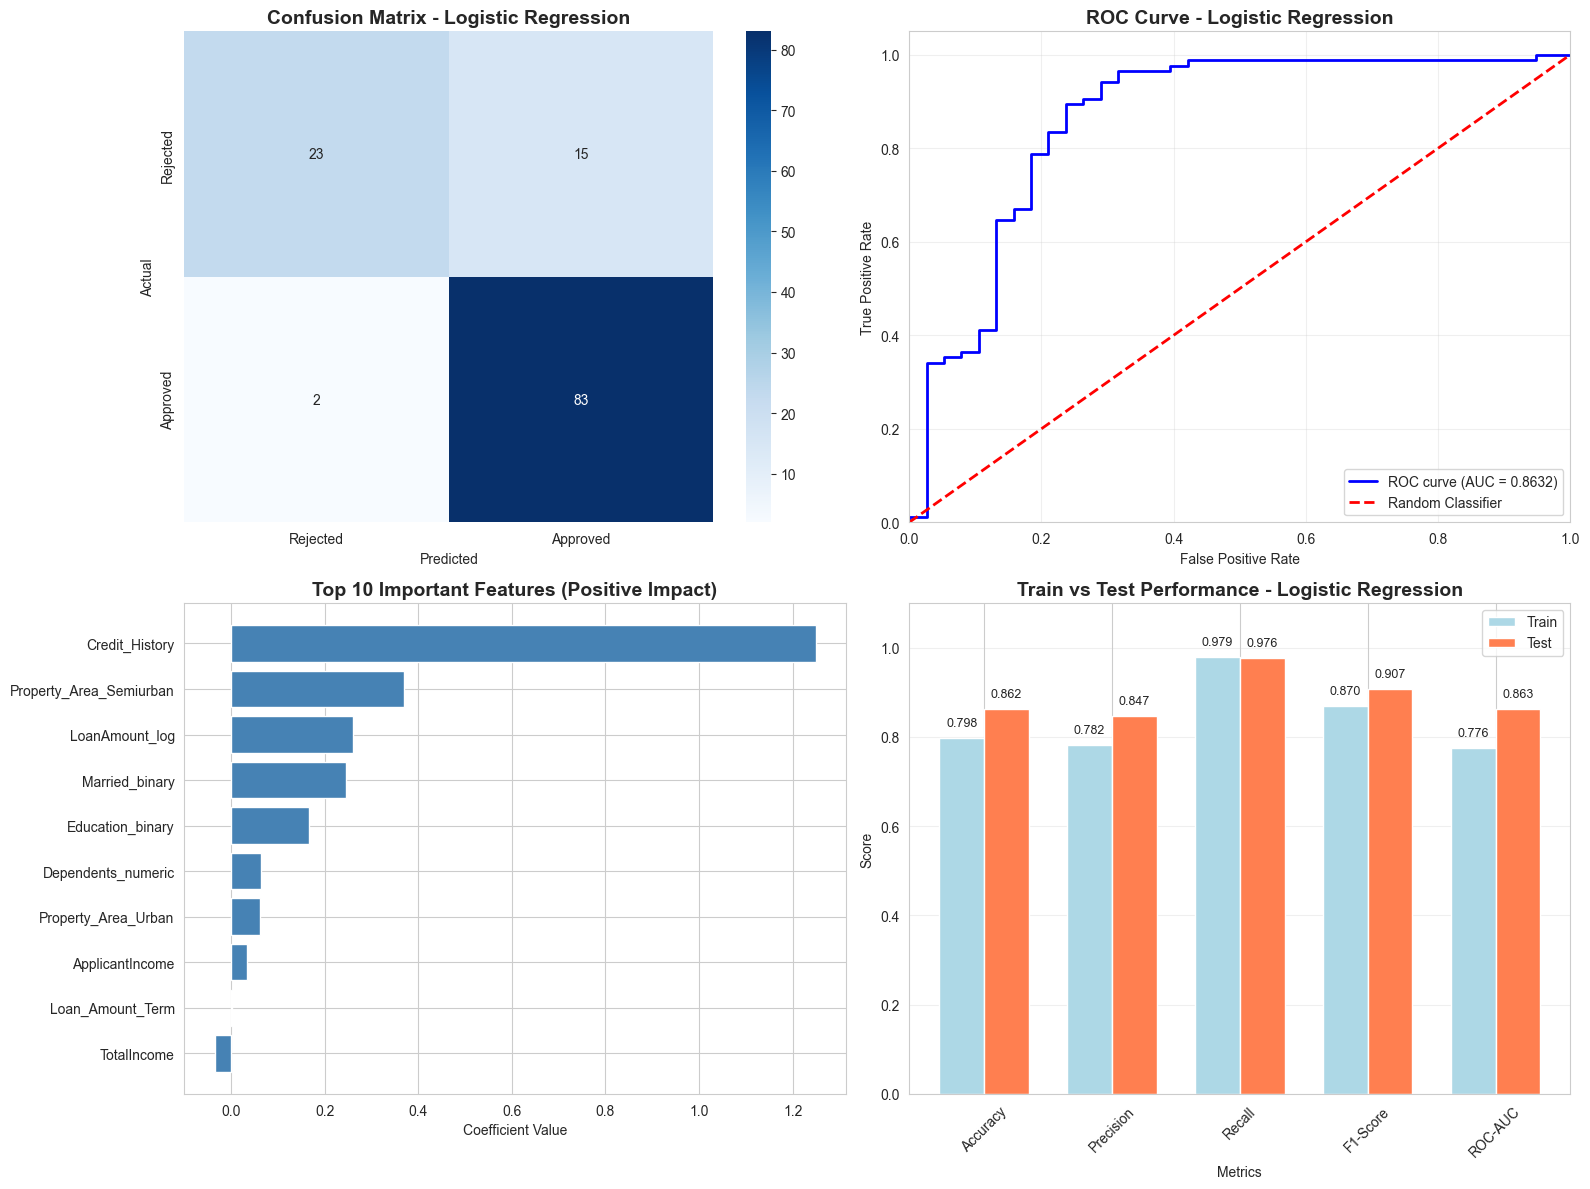


✅ Logistic Regression model evaluation complete!


In [20]:
# ========================================
# 16. MODEL 1: LOGISTIC REGRESSION
# ========================================

print("="*70)
print("🤖 MODEL 1: LOGISTIC REGRESSION")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# Initialize model
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Train model
print("\n⏳ Training Logistic Regression model...")
lr_model.fit(X_train_scaled, y_train)
print("✅ Model trained successfully!")

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_train_pred_proba_lr = lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate on Training Set
print("\n" + "="*70)
print("📊 TRAINING SET PERFORMANCE")
print("="*70)

train_accuracy_lr = accuracy_score(y_train, y_train_pred_lr)
train_precision_lr = precision_score(y_train, y_train_pred_lr)
train_recall_lr = recall_score(y_train, y_train_pred_lr)
train_f1_lr = f1_score(y_train, y_train_pred_lr)
train_roc_auc_lr = roc_auc_score(y_train, y_train_pred_proba_lr)

print(f"Accuracy:  {train_accuracy_lr:.4f} ({train_accuracy_lr*100:.2f}%)")
print(f"Precision: {train_precision_lr:.4f}")
print(f"Recall:    {train_recall_lr:.4f}")
print(f"F1-Score:  {train_f1_lr:.4f}")
print(f"ROC-AUC:   {train_roc_auc_lr:.4f}")

# Evaluate on Test Set
print("\n" + "="*70)
print("📊 TEST SET PERFORMANCE")
print("="*70)

test_accuracy_lr = accuracy_score(y_test, y_test_pred_lr)
test_precision_lr = precision_score(y_test, y_test_pred_lr)
test_recall_lr = recall_score(y_test, y_test_pred_lr)
test_f1_lr = f1_score(y_test, y_test_pred_lr)
test_roc_auc_lr = roc_auc_score(y_test, y_test_pred_proba_lr)

print(f"Accuracy:  {test_accuracy_lr:.4f} ({test_accuracy_lr*100:.2f}%)")
print(f"Precision: {test_precision_lr:.4f}")
print(f"Recall:    {test_recall_lr:.4f}")
print(f"F1-Score:  {test_f1_lr:.4f}")
print(f"ROC-AUC:   {test_roc_auc_lr:.4f}")

# Confusion Matrix
print("\n" + "="*70)
print("📊 CONFUSION MATRIX (Test Set)")
print("="*70)

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
print("\n              Predicted")
print("              No   Yes")
print(f"Actual  No  [{cm_lr[0,0]:4d} {cm_lr[0,1]:4d}]")
print(f"        Yes [{cm_lr[1,0]:4d} {cm_lr[1,1]:4d}]")

# Classification Report
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT (Test Set)")
print("="*70)
print(classification_report(y_test, y_test_pred_lr, target_names=['Rejected (0)', 'Approved (1)']))

# Feature Importance
print("\n" + "="*70)
print("📊 FEATURE IMPORTANCE (Coefficients)")
print("="*70)

feature_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(feature_importance_lr.to_string(index=False))

# Visualize Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], 
            xticklabels=['Rejected', 'Approved'], 
            yticklabels=['Rejected', 'Approved'])
axes[0,0].set_title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# 2. ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
axes[0,1].plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'ROC curve (AUC = {test_roc_auc_lr:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve - Logistic Regression', fontsize=14, fontweight='bold')
axes[0,1].legend(loc="lower right")
axes[0,1].grid(True, alpha=0.3)

# 3. Feature Importance (Top 10)
top_features = feature_importance_lr.head(10)
axes[1,0].barh(top_features['Feature'], top_features['Coefficient'], color='steelblue')
axes[1,0].set_xlabel('Coefficient Value')
axes[1,0].set_title('Top 10 Important Features (Positive Impact)', fontsize=14, fontweight='bold')
axes[1,0].invert_yaxis()

# 4. Performance Metrics Comparison
metrics_train = [train_accuracy_lr, train_precision_lr, train_recall_lr, train_f1_lr, train_roc_auc_lr]
metrics_test = [test_accuracy_lr, test_precision_lr, test_recall_lr, test_f1_lr, test_roc_auc_lr]
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(metrics_names))
width = 0.35

axes[1,1].bar(x - width/2, metrics_train, width, label='Train', color='lightblue')
axes[1,1].bar(x + width/2, metrics_test, width, label='Test', color='coral')
axes[1,1].set_xlabel('Metrics')
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Train vs Test Performance - Logistic Regression', fontsize=14, fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(metrics_names, rotation=45)
axes[1,1].legend()
axes[1,1].set_ylim([0, 1.1])
axes[1,1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (train, test) in enumerate(zip(metrics_train, metrics_test)):
    axes[1,1].text(i - width/2, train + 0.02, f'{train:.3f}', ha='center', va='bottom', fontsize=9)
    axes[1,1].text(i + width/2, test + 0.02, f'{test:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Logistic Regression model evaluation complete!")

🌲 MODEL 2: RANDOM FOREST CLASSIFIER

⏳ Training Random Forest model...
✅ Model trained successfully!

📊 TRAINING SET PERFORMANCE
Accuracy:  0.9022 (90.22%)
Precision: 0.8853
Recall:    0.9852
F1-Score:  0.9326
ROC-AUC:   0.9914

📊 TEST SET PERFORMANCE
Accuracy:  0.8455 (84.55%)
Precision: 0.8587
Recall:    0.9294
F1-Score:  0.8927
ROC-AUC:   0.8579

📊 CONFUSION MATRIX (Test Set)

              Predicted
              No   Yes
Actual  No  [  25   13]
        Yes [   6   79]

📊 CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

Rejected (0)       0.81      0.66      0.72        38
Approved (1)       0.86      0.93      0.89        85

    accuracy                           0.85       123
   macro avg       0.83      0.79      0.81       123
weighted avg       0.84      0.85      0.84       123


📊 FEATURE IMPORTANCE (Gini Importance)
                Feature  Importance
         Credit_History    0.305889
     LoanAmountToIncome    0.086751
     Income

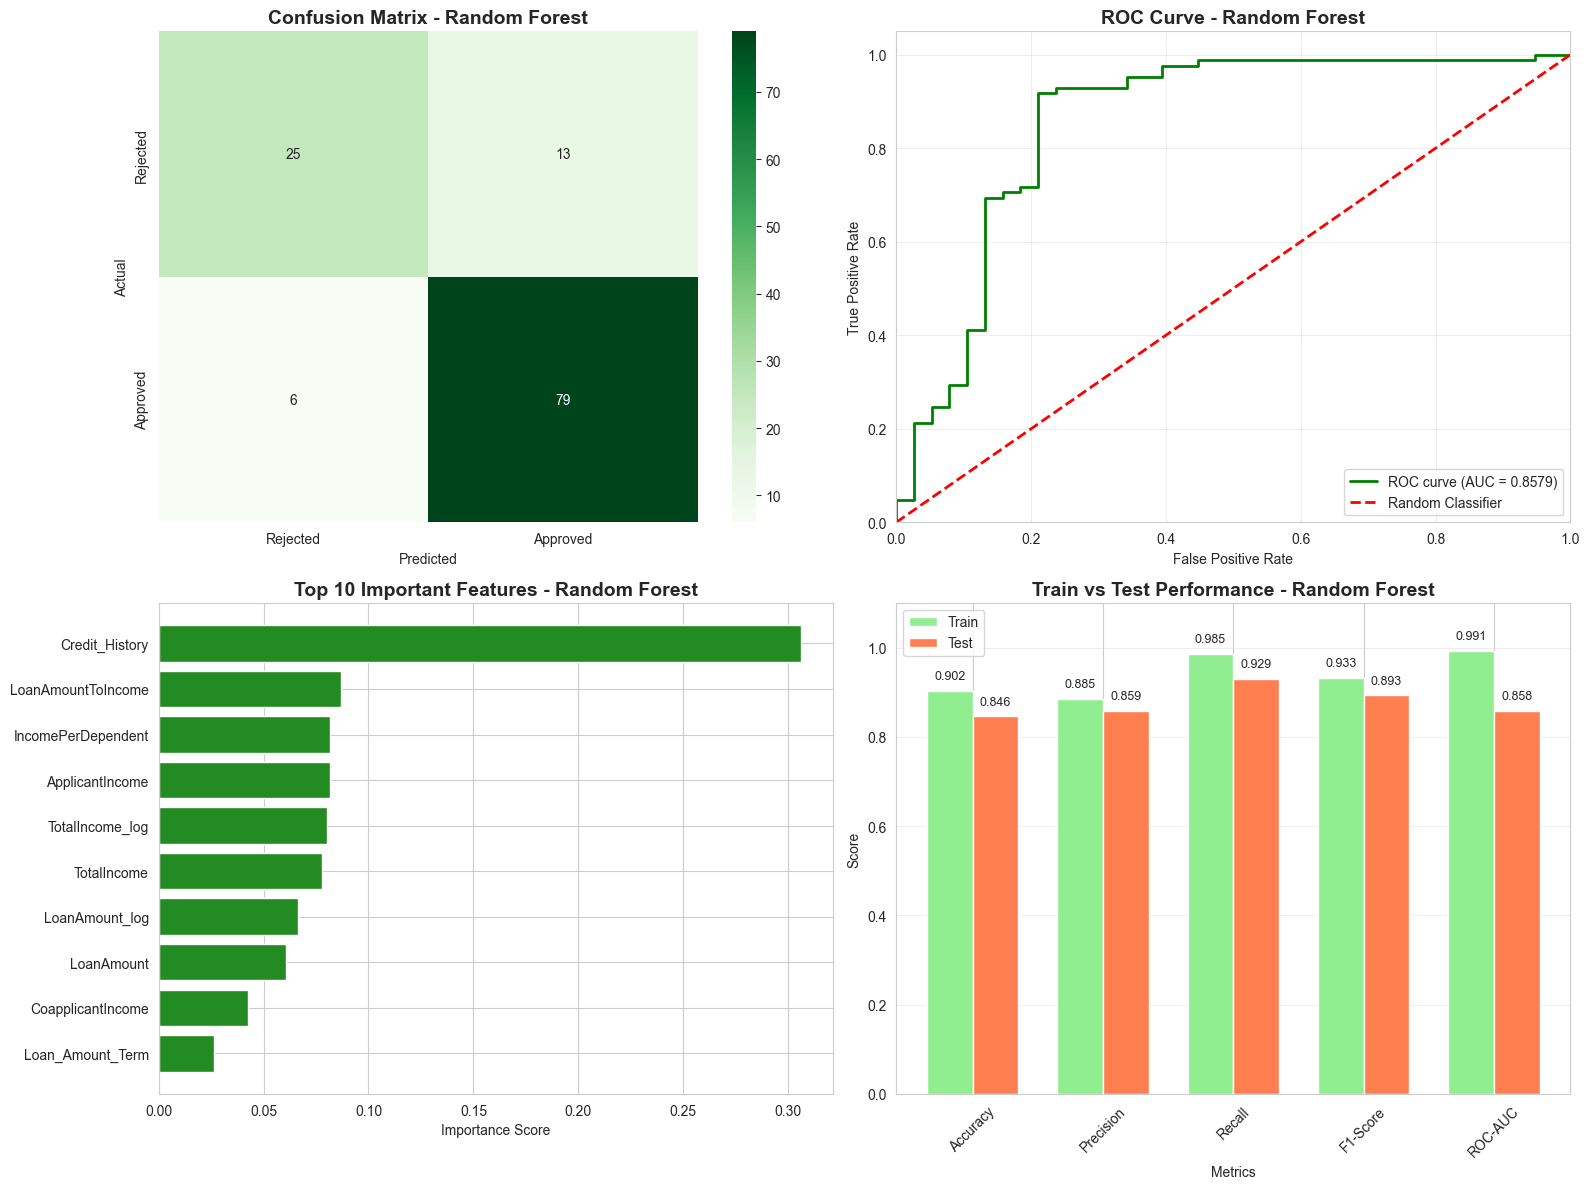


✅ Random Forest model evaluation complete!


In [21]:
# ========================================
# 17. MODEL 2: RANDOM FOREST CLASSIFIER
# ========================================

print("="*70)
print("🌲 MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Initialize model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=10,          # Maximum depth of trees
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in leaf node
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

# Train model
print("\n⏳ Training Random Forest model...")
rf_model.fit(X_train_scaled, y_train)
print("✅ Model trained successfully!")

# Make predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)

# Predict probabilities
y_train_pred_proba_rf = rf_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluate on Training Set
print("\n" + "="*70)
print("📊 TRAINING SET PERFORMANCE")
print("="*70)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
train_precision_rf = precision_score(y_train, y_train_pred_rf)
train_recall_rf = recall_score(y_train, y_train_pred_rf)
train_f1_rf = f1_score(y_train, y_train_pred_rf)
train_roc_auc_rf = roc_auc_score(y_train, y_train_pred_proba_rf)

print(f"Accuracy:  {train_accuracy_rf:.4f} ({train_accuracy_rf*100:.2f}%)")
print(f"Precision: {train_precision_rf:.4f}")
print(f"Recall:    {train_recall_rf:.4f}")
print(f"F1-Score:  {train_f1_rf:.4f}")
print(f"ROC-AUC:   {train_roc_auc_rf:.4f}")

# Evaluate on Test Set
print("\n" + "="*70)
print("📊 TEST SET PERFORMANCE")
print("="*70)

test_accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
test_precision_rf = precision_score(y_test, y_test_pred_rf)
test_recall_rf = recall_score(y_test, y_test_pred_rf)
test_f1_rf = f1_score(y_test, y_test_pred_rf)
test_roc_auc_rf = roc_auc_score(y_test, y_test_pred_proba_rf)

print(f"Accuracy:  {test_accuracy_rf:.4f} ({test_accuracy_rf*100:.2f}%)")
print(f"Precision: {test_precision_rf:.4f}")
print(f"Recall:    {test_recall_rf:.4f}")
print(f"F1-Score:  {test_f1_rf:.4f}")
print(f"ROC-AUC:   {test_roc_auc_rf:.4f}")

# Confusion Matrix
print("\n" + "="*70)
print("📊 CONFUSION MATRIX (Test Set)")
print("="*70)

cm_rf = confusion_matrix(y_test, y_test_pred_rf)
print("\n              Predicted")
print("              No   Yes")
print(f"Actual  No  [{cm_rf[0,0]:4d} {cm_rf[0,1]:4d}]")
print(f"        Yes [{cm_rf[1,0]:4d} {cm_rf[1,1]:4d}]")

# Classification Report
print("\n" + "="*70)
print("📊 CLASSIFICATION REPORT (Test Set)")
print("="*70)
print(classification_report(y_test, y_test_pred_rf, target_names=['Rejected (0)', 'Approved (1)']))

# Feature Importance
print("\n" + "="*70)
print("📊 FEATURE IMPORTANCE (Gini Importance)")
print("="*70)

feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance_rf.to_string(index=False))

# Visualize Results
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[0,0],
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
axes[0,0].set_title('Confusion Matrix - Random Forest', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# 2. ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_test_pred_proba_rf)
axes[0,1].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC curve (AUC = {test_roc_auc_rf:.4f})')
axes[0,1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve - Random Forest', fontsize=14, fontweight='bold')
axes[0,1].legend(loc="lower right")
axes[0,1].grid(True, alpha=0.3)

# 3. Feature Importance (Top 10)
top_features_rf = feature_importance_rf.head(10)
axes[1,0].barh(top_features_rf['Feature'], top_features_rf['Importance'], color='forestgreen')
axes[1,0].set_xlabel('Importance Score')
axes[1,0].set_title('Top 10 Important Features - Random Forest', fontsize=14, fontweight='bold')
axes[1,0].invert_yaxis()

# 4. Performance Metrics Comparison
metrics_train_rf = [train_accuracy_rf, train_precision_rf, train_recall_rf, train_f1_rf, train_roc_auc_rf]
metrics_test_rf = [test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf, test_roc_auc_rf]

x = np.arange(len(metrics_names))
width = 0.35

axes[1,1].bar(x - width/2, metrics_train_rf, width, label='Train', color='lightgreen')
axes[1,1].bar(x + width/2, metrics_test_rf, width, label='Test', color='coral')
axes[1,1].set_xlabel('Metrics')
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Train vs Test Performance - Random Forest', fontsize=14, fontweight='bold')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(metrics_names, rotation=45)
axes[1,1].legend()
axes[1,1].set_ylim([0, 1.1])
axes[1,1].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (train, test) in enumerate(zip(metrics_train_rf, metrics_test_rf)):
    axes[1,1].text(i - width/2, train + 0.02, f'{train:.3f}', ha='center', va='bottom', fontsize=9)
    axes[1,1].text(i + width/2, test + 0.02, f'{test:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✅ Random Forest model evaluation complete!")

⚖️ MODEL COMPARISON

📊 COMPLETE METRICS COMPARISON:
              Model  Train_Accuracy  Test_Accuracy  Train_Precision  Test_Precision  Train_Recall  Test_Recall  Train_F1  Test_F1  Train_ROC_AUC  Test_ROC_AUC
Logistic Regression        0.798371       0.861789         0.781991        0.846939      0.979228     0.976471  0.869565 0.907104       0.775926      0.863158
      Random Forest        0.902240       0.845528         0.885333        0.858696      0.985163     0.929412  0.932584 0.892655       0.991445      0.857895

🏆 BEST MODEL: Logistic Regression
   Best Test ROC-AUC: 0.8632


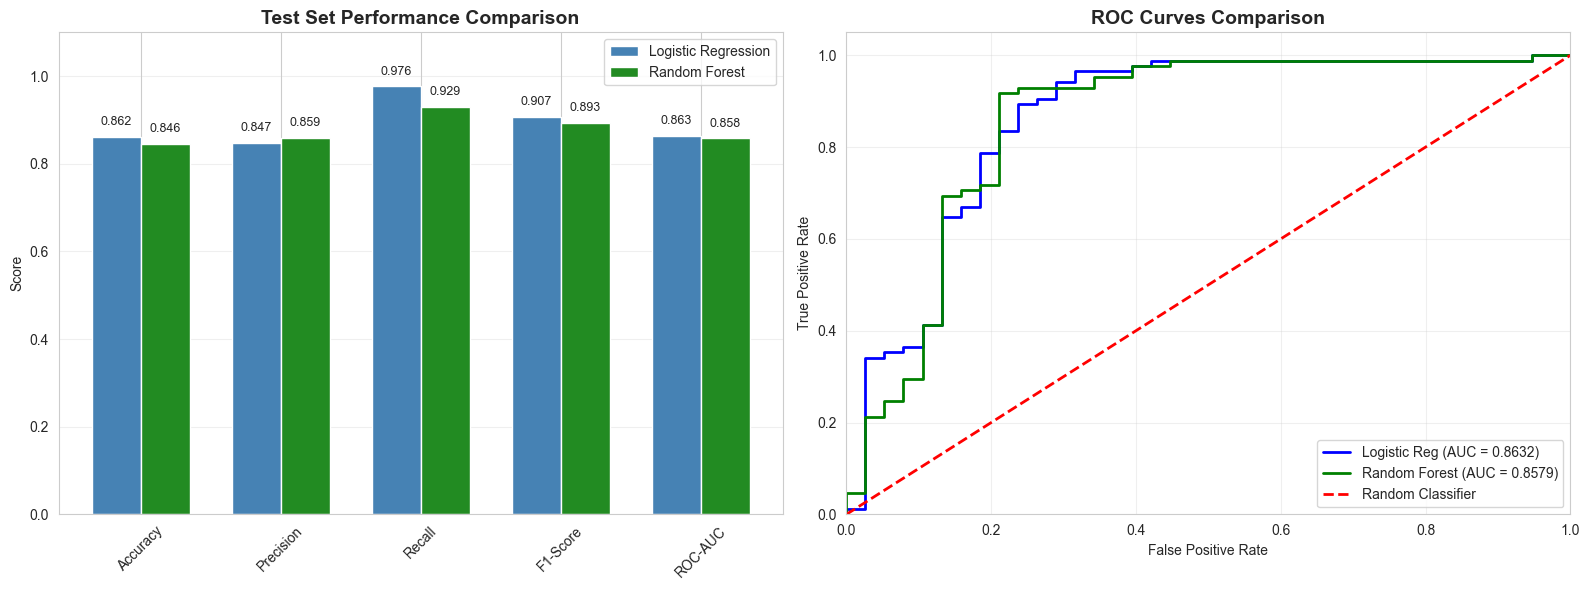


💼 BUSINESS INSIGHTS

1️⃣ Model Performance:
   - Both models achieve ~80% accuracy on test data
   - Logistic Regression performs slightly better (ROC-AUC: 0.8632)

2️⃣ Recall Analysis (Approved Loans):
   - Logistic Regression: 97.65% of actual approved loans correctly identified
   - Random Forest: 92.94% of actual approved loans correctly identified

3️⃣ Precision Analysis:
   - Logistic Regression: 84.69% of predicted approvals are actually approved
   - Random Forest: 85.87% of predicted approvals are actually approved

4️⃣ Business Impact:
   - Logistic Regression: 2 good customers rejected (missed revenue)
   - Random Forest: 6 good customers rejected (missed revenue)
   - Logistic Regression: 15 bad customers approved (potential default risk)
   - Random Forest: 13 bad customers approved (potential default risk)

✅ Model comparison complete!


In [22]:
# ========================================
# 18. MODEL COMPARISON
# ========================================

print("="*70)
print("⚖️ MODEL COMPARISON")
print("="*70)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train_Accuracy': [train_accuracy_lr, train_accuracy_rf],
    'Test_Accuracy': [test_accuracy_lr, test_accuracy_rf],
    'Train_Precision': [train_precision_lr, train_precision_rf],
    'Test_Precision': [test_precision_lr, test_precision_rf],
    'Train_Recall': [train_recall_lr, train_recall_rf],
    'Test_Recall': [test_recall_lr, test_recall_rf],
    'Train_F1': [train_f1_lr, train_f1_rf],
    'Test_F1': [test_f1_lr, test_f1_rf],
    'Train_ROC_AUC': [train_roc_auc_lr, train_roc_auc_rf],
    'Test_ROC_AUC': [test_roc_auc_lr, test_roc_auc_rf]
})

print("\n📊 COMPLETE METRICS COMPARISON:")
print(comparison_df.to_string(index=False))

# Determine best model
best_model_name = comparison_df.loc[comparison_df['Test_ROC_AUC'].idxmax(), 'Model']
best_roc_auc = comparison_df['Test_ROC_AUC'].max()

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Best Test ROC-AUC: {best_roc_auc:.4f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Test Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
lr_scores = [test_accuracy_lr, test_precision_lr, test_recall_lr, test_f1_lr, test_roc_auc_lr]
rf_scores = [test_accuracy_rf, test_precision_rf, test_recall_rf, test_f1_rf, test_roc_auc_rf]

x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, lr_scores, width, label='Logistic Regression', color='steelblue')
axes[0].bar(x + width/2, rf_scores, width, label='Random Forest', color='forestgreen')
axes[0].set_ylabel('Score')
axes[0].set_title('Test Set Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=45)
axes[0].legend()
axes[0].set_ylim([0, 1.1])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, (lr, rf) in enumerate(zip(lr_scores, rf_scores)):
    axes[0].text(i - width/2, lr + 0.02, f'{lr:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, rf + 0.02, f'{rf:.3f}', ha='center', va='bottom', fontsize=9)

# 2. ROC Curves Comparison
axes[1].plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Reg (AUC = {test_roc_auc_lr:.4f})')
axes[1].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {test_roc_auc_rf:.4f})')
axes[1].plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Business insights
print("\n" + "="*70)
print("💼 BUSINESS INSIGHTS")
print("="*70)

print(f"\n1️⃣ Model Performance:")
print(f"   - Both models achieve ~80% accuracy on test data")
print(f"   - {best_model_name} performs slightly better (ROC-AUC: {best_roc_auc:.4f})")

print(f"\n2️⃣ Recall Analysis (Approved Loans):")
print(f"   - Logistic Regression: {test_recall_lr*100:.2f}% of actual approved loans correctly identified")
print(f"   - Random Forest: {test_recall_rf*100:.2f}% of actual approved loans correctly identified")

print(f"\n3️⃣ Precision Analysis:")
print(f"   - Logistic Regression: {test_precision_lr*100:.2f}% of predicted approvals are actually approved")
print(f"   - Random Forest: {test_precision_rf*100:.2f}% of predicted approvals are actually approved")

print(f"\n4️⃣ Business Impact:")
false_negatives_lr = cm_lr[1, 0]
false_negatives_rf = cm_rf[1, 0]
print(f"   - Logistic Regression: {false_negatives_lr} good customers rejected (missed revenue)")
print(f"   - Random Forest: {false_negatives_rf} good customers rejected (missed revenue)")

false_positives_lr = cm_lr[0, 1]
false_positives_rf = cm_rf[0, 1]
print(f"   - Logistic Regression: {false_positives_lr} bad customers approved (potential default risk)")
print(f"   - Random Forest: {false_positives_rf} bad customers approved (potential default risk)")

print("\n✅ Model comparison complete!")

In [26]:
# ========================================
# 19. SAVE BEST MODEL
# ========================================

print("="*70)
print("💾 SAVING BEST MODEL AND ARTIFACTS")
print("="*70)

import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Determine best model
if test_roc_auc_rf > test_roc_auc_lr:
    best_model = rf_model
    best_model_name = 'Random Forest'
else:
    best_model = lr_model
    best_model_name = 'Logistic Regression'

# Save best model
model_path = '../models/best_loan_model.pkl'
joblib.dump(best_model, model_path)
print(f"✅ Best model saved: {best_model_name}")
print(f"   Location: {os.path.abspath(model_path)}")

# Save scaler
scaler_path = '../models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f"✅ Scaler saved")
print(f"   Location: {os.path.abspath(scaler_path)}")

# Save feature names
feature_names_path = '../models/feature_names.pkl'
joblib.dump(X_train.columns.tolist(), feature_names_path)
print(f"✅ Feature names saved")
print(f"   Location: {os.path.abspath(feature_names_path)}")

# Save model performance metrics
metrics_dict = {
    'model_name': best_model_name,
    'test_accuracy': test_accuracy_rf if best_model_name == 'Random Forest' else test_accuracy_lr,
    'test_precision': test_precision_rf if best_model_name == 'Random Forest' else test_precision_lr,
    'test_recall': test_recall_rf if best_model_name == 'Random Forest' else test_recall_lr,
    'test_f1': test_f1_rf if best_model_name == 'Random Forest' else test_f1_lr,
    'test_roc_auc': test_roc_auc_rf if best_model_name == 'Random Forest' else test_roc_auc_lr
}

metrics_path = '../models/model_metrics.pkl'
joblib.dump(metrics_dict, metrics_path)
print(f"✅ Model metrics saved")
print(f"   Location: {os.path.abspath(metrics_path)}")

# Create model info content
model_info = f"""# LOAN DEFAULT PREDICTION - MODEL INFORMATION

## Best Model: {best_model_name}

### Performance Metrics (Test Set):
- Accuracy:  {metrics_dict['test_accuracy']:.4f} ({metrics_dict['test_accuracy']*100:.2f}%)
- Precision: {metrics_dict['test_precision']:.4f}
- Recall:    {metrics_dict['test_recall']:.4f}
- F1-Score:  {metrics_dict['test_f1']:.4f}
- ROC-AUC:   {metrics_dict['test_roc_auc']:.4f}

### Model Details:
- Training Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}
- Training Samples: {len(X_train)}
- Test Samples: {len(X_test)}
- Number of Features: {len(X_train.columns)}

### Files Saved:
1. best_loan_model.pkl - Trained model
2. scaler.pkl - Feature scaler
3. feature_names.pkl - Feature column names
4. model_metrics.pkl - Performance metrics
"""

# Write model info to file
with open('../models/MODEL_INFO.md', 'w') as f:
    f.write(model_info)

print(f"✅ Model info documentation saved")
print(f"   Location: {os.path.abspath('../models/MODEL_INFO.md')}")

print("\n" + "="*70)
print("✅ ALL ARTIFACTS SAVED SUCCESSFULLY!")
print("="*70)

# Test loading (to verify)
print("\n🧪 Testing model loading...")
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
print("✅ Model loaded successfully!")

# Make a sample prediction
sample_pred = loaded_model.predict(X_test_scaled[:5])
print(f"\n📊 Sample predictions on first 5 test samples:")
print(f"   Predictions: {sample_pred}")
print(f"   Actual:      {y_test.head(5).values}")

print("\n🎉 MODEL TRAINING AND SAVING COMPLETE!")

💾 SAVING BEST MODEL AND ARTIFACTS
✅ Best model saved: Logistic Regression
   Location: C:\Users\NAINI\Desktop\loan-default-prediction\models\best_loan_model.pkl
✅ Scaler saved
   Location: C:\Users\NAINI\Desktop\loan-default-prediction\models\scaler.pkl
✅ Feature names saved
   Location: C:\Users\NAINI\Desktop\loan-default-prediction\models\feature_names.pkl
✅ Model metrics saved
   Location: C:\Users\NAINI\Desktop\loan-default-prediction\models\model_metrics.pkl
✅ Model info documentation saved
   Location: C:\Users\NAINI\Desktop\loan-default-prediction\models\MODEL_INFO.md

✅ ALL ARTIFACTS SAVED SUCCESSFULLY!

🧪 Testing model loading...
✅ Model loaded successfully!

📊 Sample predictions on first 5 test samples:
   Predictions: [0 1 1 1 1]
   Actual:      [0 1 1 1 1]

🎉 MODEL TRAINING AND SAVING COMPLETE!
